In [1]:
import pandas as pd
import sqlite3
import os

db = os.path.abspath('./data/finance.db')
print('db path:', db)
print('exists:', os.path.exists(db))

conn = sqlite3.connect(db)

# First check what tables exist
cur = conn.cursor()
cur.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cur.fetchall()
print('tables:', tables)

# If tables exist, read from the first one
if tables:
    table_name = tables[0][0]
    print(f"\nReading from {table_name}:")
    df = pd.read_sql(f"SELECT * FROM {table_name} LIMIT 10;", conn)
    print(df.head())
else:
    print("\nNo tables found in database!")

conn.close()

db path: d:\Projects\Data_pipeline\finance-pipeline\data\finance.db
exists: True
tables: [('FB_data',), ('AAPL_data',), ('GOOGL_data',), ('AMZN_data',), ('META_data',), ('MSFT_data',), ('TSLA_data',), ('NVDA_data',), ('BABA_data',), ('TSM_data',), ('AVGO_data',), ('PINS_data',)]

Reading from FB_data:
                 ('Date', '') ('MA_20', '') ('Vol20', '')  ('Returns', '')
0  2025-06-26 00:00:00.000000          None          None              NaN
1  2025-06-27 00:00:00.000000          None          None         0.008494
2  2025-06-30 00:00:00.000000          None          None         0.005590
3  2025-07-01 00:00:00.000000          None          None        -0.001977
4  2025-07-02 00:00:00.000000          None          None        -0.003565


In [3]:
df

,"('Date', '')","('MA_20', '')","('Vol20', '')","('Returns', '')"
0,2025-06-26 00:00:00.000000,None,None,NaN
1,2025-06-27 00:00:00.000000,None,None,0.008494
2,2025-06-30 00:00:00.000000,None,None,0.005590
3,2025-07-01 00:00:00.000000,None,None,-0.001977
4,2025-07-02 00:00:00.000000,None,None,-0.003565
5,2025-07-03 00:00:00.000000,None,None,0.006559
6,2025-07-07 00:00:00.000000,None,None,0.000889
7,2025-07-08 00:00:00.000000,None,None,-0.003452
8,2025-07-09 00:00:00.000000,None,None,0.000866
9,2025-07-10 00:00:00.000000,None,None,0.000767


In [22]:
conn = sqlite3.connect(db)
df = pd.read_sql(f"SELECT * FROM {'PINS_data'} LIMIT 500;", conn)
conn.close()

In [23]:
df

,"('Date', '')","('MA_20', '')","('Vol20', '')","('Returns', '')"
0,2024-01-02 00:00:00.000000,NaN,NaN,NaN
1,2024-01-03 00:00:00.000000,NaN,NaN,-0.009666
2,2024-01-04 00:00:00.000000,NaN,NaN,-0.002231
3,2024-01-05 00:00:00.000000,NaN,NaN,0.003913
4,2024-01-08 00:00:00.000000,NaN,NaN,0.040646
...,...,...,...,...
495,2025-12-22 00:00:00.000000,26.4115,3.370128,0.011886
496,2025-12-23 00:00:00.000000,26.4730,3.349503,-0.014020
497,2025-12-24 00:00:00.000000,26.5040,3.299915,0.004227
498,2025-12-26 00:00:00.000000,26.5325,3.236724,0.000383


In [24]:
columns = df.columns.get_level_values(0)
columns
# the multilevel index removal actually did not work
# this is likely a fake multilevel index, meaning the column name itself is a tuple

Index(['('Date', '')', '('MA_20', '')', '('Vol20', '')', '('Returns', '')'], dtype='object')

In [25]:
print(type(df.columns))

<class 'pandas.core.indexes.base.Index'>


In [27]:
df.columns

Index(['('Date', '')', '('MA_20', '')', '('Vol20', '')', '('Returns', '')'], dtype='object')

In [26]:
# remove multilevel index as the latter is empty
df.columns = pd.MultiIndex.from_tuples(df.columns)
df.columns = df.columns.get_level_values(0)
df

TypeError: Expected tuple, got str

In [ ]:
#columns are a mix of data types. Some columns are tuples, but at least one column is a plain string
df.columns = [col if isinstance(col, tuple) else (col,) for col in df.columns]

# 2. Convert the list of tuples into a proper MultiIndex
df.columns = pd.MultiIndex.from_tuples(df.columns)

# 3. Now get_level_values(0) will work without error
df.columns = df.columns.get_level_values(0)

In [30]:
df.columns

Index(['('Date', '')', '('MA_20', '')', '('Vol20', '')', '('Returns', '')'], dtype='object')

In [32]:
"""
When you pass a MultiIndex DataFrame to to_sql, 
some database drivers (like sqlite or psycopg2) do not support hierarchical headers. 
To compensate, they convert the Python tuple ('Date', '') into a literal string "('Date', '')" to fit it into a single SQL column. 
When you read it back, Pandas treats that string as the literal name rather than a structure.
"""

'\nWhen you pass a MultiIndex DataFrame to to_sql, \nsome database drivers (like sqlite or psycopg2) do not support hierarchical headers. \nTo compensate, they convert the Python tuple (\'Date\', \'\') into a literal string "(\'Date\', \'\')" to fit it into a single SQL column. \nWhen you read it back, Pandas treats that string as the literal name rather than a structure.\n'

In [36]:
df.columns = (
    df.columns.str.replace(r"[()']", "", regex=True)
              .str.replace(r",\s*$", "", regex=True)
)

print(df.columns) 

Index(['MA_20', 'Vol20', 'Returns'], dtype='object')


Text(0.5, 0, 'Date')

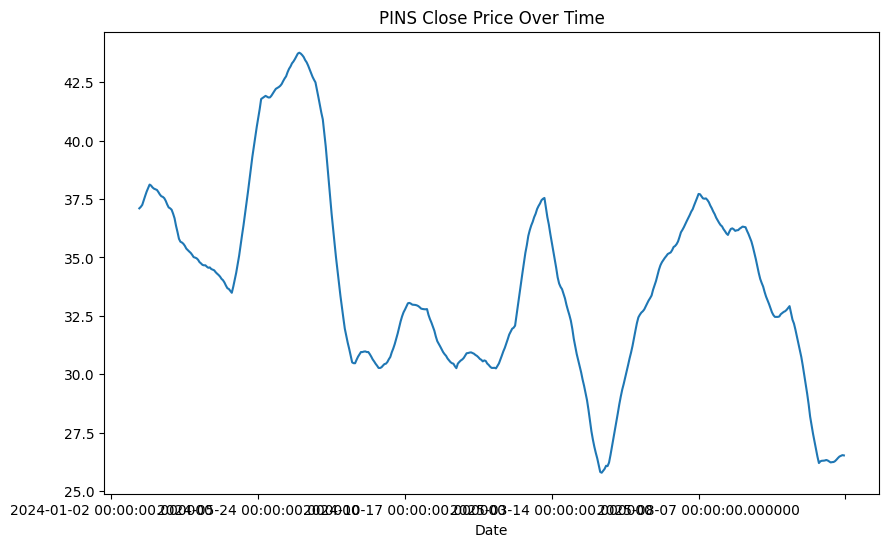

In [37]:
import matplotlib.pyplot as plt
#df.set_index('Date', inplace=True)
df['MA_20'].plot(title='PINS Close Price Over Time', figsize=(10,6))
plt.xlabel('Date')